In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [5]:
data=pd.read_csv(r"C:\Users\abody\Desktop\Final Project Sprints\Heart_Disease_Project\data\Cleaned")
df=pd.DataFrame(data) 

In [6]:
X = df.drop(columns=["Target"])
y = df["Target"]

In [7]:
# Initialize PCA without specifying n_components yet
pca = PCA()
X_pca = pca.fit_transform(X)  # Fit and transform the dataset


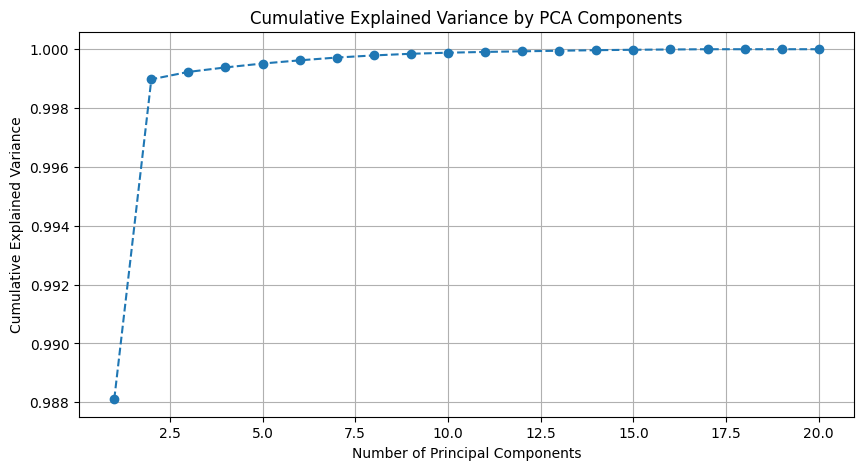

PC1: 0.9881 (0.9881 cumulative)
PC2: 0.0109 (0.9990 cumulative)
PC3: 0.0003 (0.9992 cumulative)
PC4: 0.0002 (0.9994 cumulative)
PC5: 0.0001 (0.9995 cumulative)
PC6: 0.0001 (0.9996 cumulative)
PC7: 0.0001 (0.9997 cumulative)
PC8: 0.0001 (0.9998 cumulative)
PC9: 0.0001 (0.9998 cumulative)
PC10: 0.0000 (0.9999 cumulative)
PC11: 0.0000 (0.9999 cumulative)
PC12: 0.0000 (0.9999 cumulative)
PC13: 0.0000 (0.9999 cumulative)
PC14: 0.0000 (1.0000 cumulative)
PC15: 0.0000 (1.0000 cumulative)
PC16: 0.0000 (1.0000 cumulative)
PC17: 0.0000 (1.0000 cumulative)
PC18: 0.0000 (1.0000 cumulative)
PC19: 0.0000 (1.0000 cumulative)
PC20: 0.0000 (1.0000 cumulative)


In [8]:
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Plot cumulative variance to determine optimal number of components
plt.figure(figsize=(10,5))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o', linestyle='--')
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

# Optional: print variance retained per component
for i, var in enumerate(explained_var, start=1):
    print(f"PC{i}: {var:.4f} ({cumulative_var[i-1]:.4f} cumulative)")


In [9]:
n_components = np.argmax(cumulative_var >= 0.95) + 1  # Retain 95% variance
pca_final = PCA(n_components=n_components)
X_pca_final = pca_final.fit_transform(X)

print(f"Selected {n_components} components to retain 95% variance")


Selected 1 components to retain 95% variance


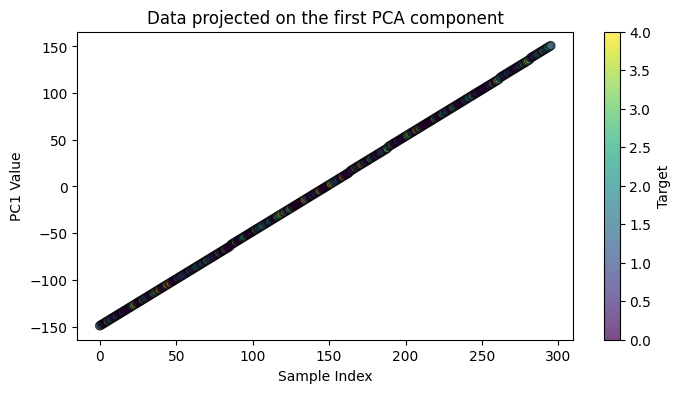

In [11]:
plt.figure(figsize=(8,4))
plt.scatter(range(len(X_pca)), X_pca[:,0], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
plt.xlabel("Sample Index")
plt.ylabel("PC1 Value")
plt.title("Data projected on the first PCA component")
plt.colorbar(label="Target")
plt.show()
